# Modèle A — Nettoyage du dataset MUCars-2024 (étape A.2)

**Objectif** : préparer les données d'entraînement du modèle d'estimation du prix d'un véhicule d'occasion.

**Source** : *Moroccan Used Cars Dataset (MUCars-2024)* — E. Tabarnoust, M. Mghari, Y. Zaz (Université Abdelmalek Essaâdi),
Mendeley Data, DOI [10.17632/vjrbcb2rrt.2](https://doi.org/10.17632/vjrbcb2rrt.2), licence CC BY 4.0. 101 896 annonces collectées en 2024.

Le nettoyage est fait par `ml/src/model_a/clean.py` ; ce notebook en présente les résultats.

> **Limite** : ce sont des **prix demandés** dans des annonces, pas des prix de transaction. Le modèle estimera la valeur affichée sur le marché.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ML_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ML_DIR / "src" / "model_a"))
import clean

FIG_DIR = ML_DIR / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

brut = pd.read_csv(clean.RAW_PATH)
propre, etapes = clean.nettoyer(brut)
print(f"{len(brut):,} annonces brutes -> {len(propre):,} annonces propres ({len(propre)/len(brut):.1%})")

101,896 annonces brutes -> 70,368 annonces propres (69.1%)


## 1. Règles de nettoyage appliquées

Chaque règle est appliquée dans l'ordre ; le tableau indique combien d'annonces elle a écartées.

In [2]:
tableau = pd.DataFrame(etapes).rename(columns={"regle": "Règle", "lignes_retirees": "Retirées", "lignes_restantes": "Restantes"})
tableau["% du brut"] = (tableau["Retirées"] / len(brut) * 100).round(2)
tableau

,Règle,Retirées,Restantes,% du brut
0,dataset brut,0,101896,0.00
1,doublons exacts,2805,99091,2.75
2,prix manquant,24421,74670,23.97
3,marque ou modèle manquant,1,74669,0.00
4,marque invalide (numérique),116,74553,0.11
5,véhicule accidenté / pour pièces,118,74435,0.12
6,carburant invalide,0,74435,0.00
7,"prix hors [15,000 ; 1,500,000] DH",1374,73061,1.35
8,incohérence état neuf / kilométrage > 50 000 km,1605,71456,1.58
9,prix aberrant vs annonces comparables (> 3.5 MAD),785,70671,0.77


Justification des règles principales :

| Règle | Justification |
|---|---|
| Prix manquant | Pas de valeur cible, inutilisable en apprentissage supervisé |
| Prix hors [15 000 ; 1 500 000] DH | En dessous : épaves, acomptes, prix mensuels ; au-dessus : zéros en trop |
| Accidenté / pour pièces | Valeur non comparable à un véhicule roulant |
| Neuf avec > 50 000 km | Incohérence entre deux champs saisis par le vendeur |
| Prix aberrant vs comparables | Prix > ~2× ou < ~0,5× la médiane du même marque + modèle + tranche d'âge (score MAD robuste > 3,5 sur le log du prix, groupes ≥ 10 annonces) |
| Kilométrage < 3 000 km/an pour un véhicule de 3 ans ou plus | Invraisemblable (moyenne marocaine ~15 000 km/an) : valeur par défaut « 0 - 4 999 » ou zéro oublié. Remplacé par « inconnu » (colonne `km_inconnu`) — l'annonce est gardée, son prix reste valide |

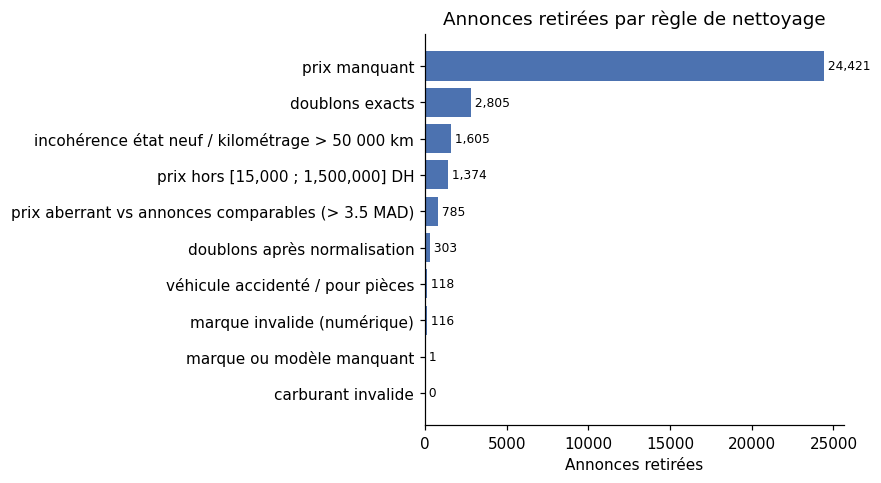

In [3]:
fig, ax = plt.subplots(figsize=(8, 4.5))
retraits = tableau.iloc[1:].sort_values("Retirées")
ax.barh(retraits["Règle"], retraits["Retirées"], color="#4C72B0")
for y, v in enumerate(retraits["Retirées"]):
    ax.text(v, y, f" {v:,}", va="center", fontsize=8)
ax.set_xlabel("Annonces retirées")
ax.set_title("Annonces retirées par règle de nettoyage")
fig.tight_layout(); fig.savefig(FIG_DIR / "a2_regles_nettoyage.png"); plt.show()

## 2. Distribution des prix avant / après

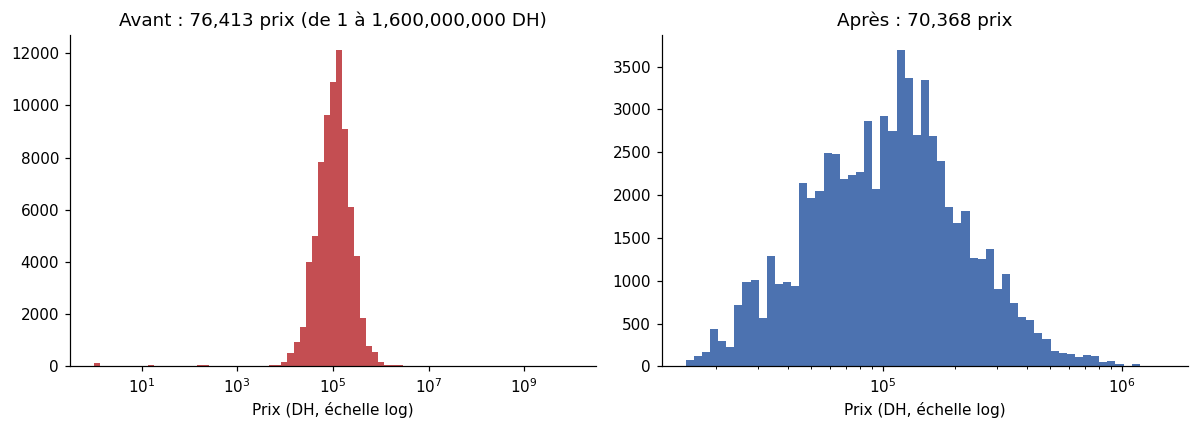

,count,mean,std,min,25%,50%,75%,max
prix (DH),70368.0,135620.0,114250.0,15000.0,62000.0,108000.0,167000.0,1450000.0


In [4]:
prix_brut = brut["Price"].dropna()
prix_brut = prix_brut[prix_brut > 0]
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=False)
bins = np.logspace(0, 10, 80)
axes[0].hist(prix_brut, bins=bins, color="#C44E52")
axes[0].set_xscale("log"); axes[0].set_title(f"Avant : {len(prix_brut):,} prix (de {prix_brut.min():,.0f} à {prix_brut.max():,.0f} DH)")
axes[1].hist(propre["prix"], bins=np.logspace(np.log10(15_000), np.log10(1_500_000), 60), color="#4C72B0")
axes[1].set_xscale("log"); axes[1].set_title(f"Après : {len(propre):,} prix")
for ax in axes: ax.set_xlabel("Prix (DH, échelle log)")
fig.tight_layout(); fig.savefig(FIG_DIR / "a2_prix_avant_apres.png"); plt.show()
propre["prix"].describe().round(0).to_frame("prix (DH)").T

## 3. Qualité du jeu propre

In [5]:
manquants = propre.isna().mean().mul(100).round(2)
print("Valeurs manquantes (%) :")
print(manquants[manquants > 0].to_string())
print()
print(f"Kilométrage inconnu : {propre['km_inconnu'].mean():.1%}")
print(f"Marques : {propre['marque'].nunique()} — modèles : {propre.groupby('marque')['modele'].nunique().sum()} — villes : {propre['ville'].nunique()}")
propre.head()

Valeurs manquantes (%) :
kilometrage          16.19
puissance_fiscale     0.26
nb_portes             9.87
secteur               0.24

Kilométrage inconnu : 16.2%
Marques : 63 — modèles : 952 — villes : 358


,marque,modele,annee,age,kilometrage,km_inconnu,boite,puissance_fiscale,carburant,etat,...,eq_abs,eq_sieges_cuir,eq_limiteur_vitesse,eq_regulateur_vitesse,eq_radar_recul,eq_ordinateur_bord,eq_esp,eq_gps,eq_toit_ouvrant,prix
0,volkswagen,polo,1997,27,225000.0,False,manuelle,8.0,diesel,bon,...,False,True,False,False,False,False,False,False,False,27000
1,dacia,sandero,2012,12,185000.0,False,manuelle,6.0,diesel,tres_bon,...,False,False,False,False,False,False,False,False,False,69000
2,volkswagen,polo,2004,20,325000.0,False,manuelle,8.0,diesel,correct,...,False,False,False,False,False,False,False,False,False,45000
3,bentley,continental gtc,2009,15,47500.0,False,automatique,34.0,essence,excellent,...,False,False,False,False,False,False,False,False,False,720000
4,mini,cooper,2013,11,87500.0,False,automatique,8.0,diesel,excellent,...,False,True,True,True,True,True,True,True,False,128000


## 4. Premiers constats (prix vs variables)

Ces relations confirment que les variables disponibles expliquent le prix, avant tout modèle.

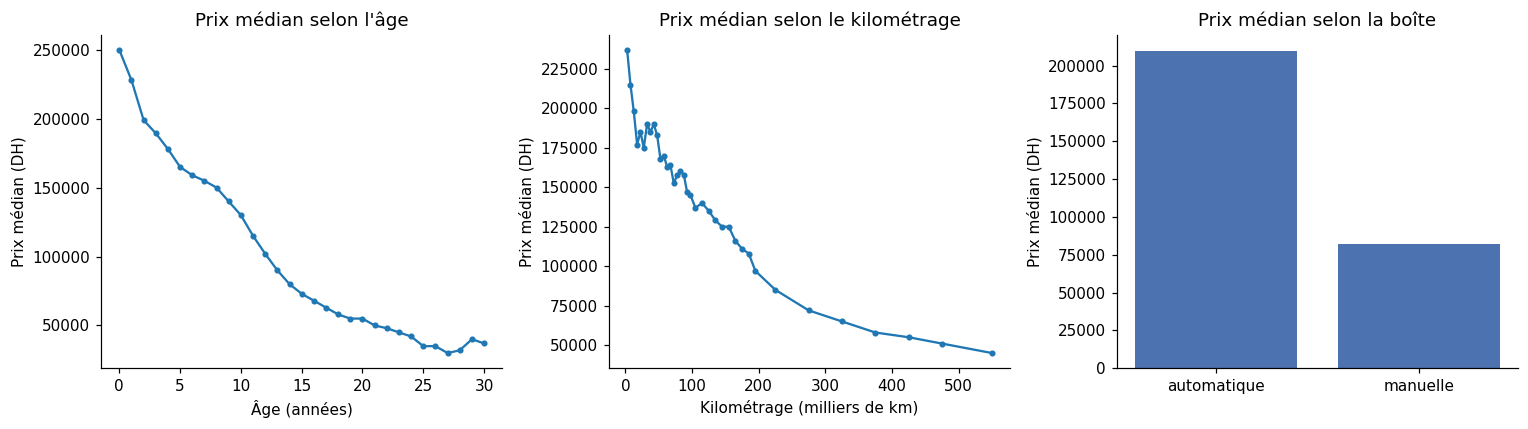

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
m = propre.groupby("age")["prix"].median()
m = m[m.index <= 30]
axes[0].plot(m.index, m.values, marker="o", ms=3); axes[0].set_title("Prix médian selon l'âge"); axes[0].set_xlabel("Âge (années)")
k = propre.dropna(subset=["kilometrage"]).groupby("kilometrage")["prix"].median()
axes[1].plot(k.index / 1000, k.values, marker="o", ms=3); axes[1].set_title("Prix médian selon le kilométrage"); axes[1].set_xlabel("Kilométrage (milliers de km)")
b = propre.groupby("boite")["prix"].median()
axes[2].bar(b.index, b.values, color="#4C72B0"); axes[2].set_title("Prix médian selon la boîte")
for ax in axes: ax.set_ylabel("Prix médian (DH)")
fig.tight_layout(); fig.savefig(FIG_DIR / "a2_prix_vs_variables.png"); plt.show()

**Constat qui a motivé la règle kilométrage** : sur le jeu brut, les tranches 5 000 – 35 000 km avaient un prix médian *plus bas* que 60 000 km, car elles contenaient surtout des voitures de 10 à 15 ans (500 à 2 000 km/an déclarés). Une fois ces kilométrages passés en « inconnu », la courbe ci-dessus devient décroissante, comme attendu.

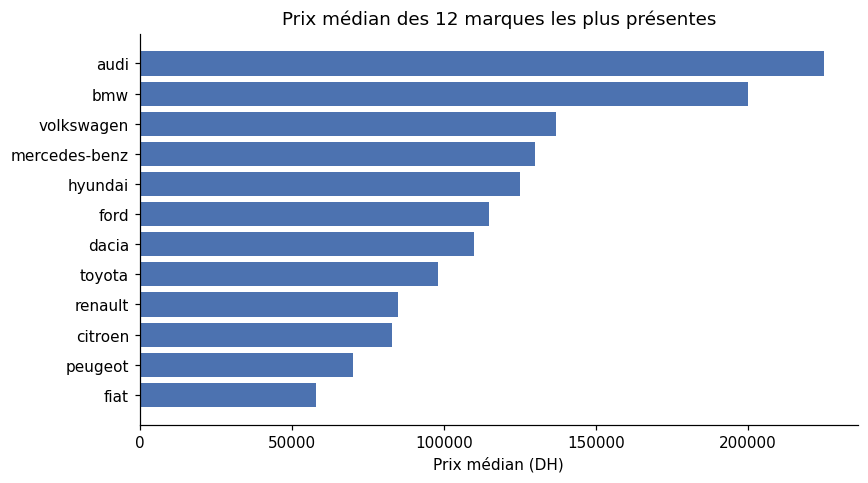

,count,median
marque,,
fiat,4452,58000
peugeot,6543,70000
citroen,3042,83000
renault,8631,85000
toyota,1946,98000
dacia,5808,110000
ford,3654,115000
hyundai,3803,125000
mercedes-benz,4997,130000


In [7]:
top = propre["marque"].value_counts().head(12).index
stats = propre[propre["marque"].isin(top)].groupby("marque")["prix"].agg(["count", "median"]).sort_values("median")
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(stats.index, stats["median"], color="#4C72B0")
ax.set_xlabel("Prix médian (DH)"); ax.set_title("Prix médian des 12 marques les plus présentes")
fig.tight_layout(); fig.savefig(FIG_DIR / "a2_prix_marques.png"); plt.show()
stats.astype(int)

## Conclusion

- Jeu propre : environ **70 000 annonces** (69 % du brut), sans prix aberrant, avec des variables typées et en français.
- Les règles sont **déterministes et documentées** (`clean.py`), relançables à l'identique.
- Le regroupement des modèles rares et l'encodage des catégories seront faits à l'étape A.3, **sur le seul jeu d'entraînement**, pour éviter toute fuite d'information vers le jeu de test.

**Étape suivante (A.3)** : séparation entraînement / validation / test, variables dérivées, modèle de référence.